In [5]:
# Importamos las librerías necesarias
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Configuramos el estilo de los gráficos para que se vean mejor
plt.style.use('seaborn-v0_8-darkgrid')

print("Librerías importadas correctamente. ¡Listo para descargar datos!")

Librerías importadas correctamente. ¡Listo para descargar datos!


Descargando datos de BTC-USD...


[*********************100%***********************]  1 of 1 completed


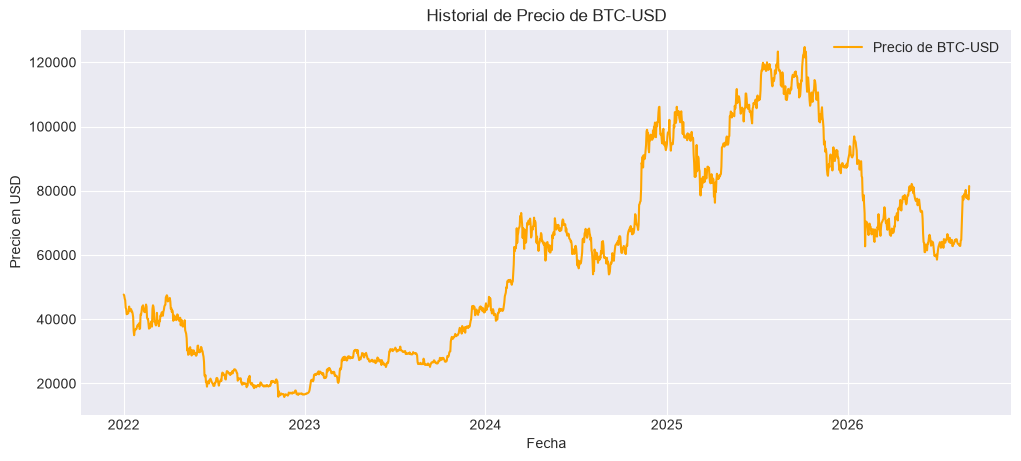

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-08-30,77667.570312,79373.179688,77056.148438,78246.171875,19314839672
2026-08-31,78548.632812,79247.343750,77378.437500,77673.703125,30608386987
2026-09-01,77403.625000,79196.515625,76399.062500,78539.859375,30608796575
2026-09-02,77300.476562,77737.546875,76248.304688,77402.140625,26525296646
2026-09-03,81467.648438,81763.437500,76993.968750,77310.171875,36595150848


In [6]:
# Definimos el activo (ticker) y las fechas
ticker = "BTC-USD"
fecha_inicio = "2022-01-01"

print(f"Descargando datos de {ticker}...")
# Descargamos los datos históricos
datos = yf.download(ticker, start=fecha_inicio)

# Mostramos un gráfico del precio de Cierre (Close)
plt.figure(figsize=(12, 5))
plt.plot(datos['Close'], label=f'Precio de {ticker}', color='orange')
plt.title(f"Historial de Precio de {ticker}")
plt.xlabel("Fecha")
plt.ylabel("Precio en USD")
plt.legend()
plt.show()

# Mostramos las últimas 5 filas de la tabla de datos
datos.tail()

In [7]:
# 1. Calculamos el Promedio Móvil Simple de 20 días
datos['SMA_20'] = datos['Close'].rolling(window=20).mean()

# 2. Calculamos el Retorno Diario (porcentaje de cambio respecto al día anterior)
datos['Retorno_Diario'] = datos['Close'].pct_change()

# 3. CREAMOS LA VARIABLE OBJETIVO (TARGET) PARA LA IA
# Comparamos si el precio de cierre de "mañana" (shift(-1)) es mayor al de hoy.
# El resultado es True/False, al multiplicarlo por 1 se convierte en 1 o 0.
datos['Target'] = (datos['Close'].shift(-1) > datos['Close']).astype(int)

# Como usamos promedios de 20 días y buscamos hacia el futuro (shift), 
# se generarán filas vacías (NaN) al principio y al final. Las eliminamos:
datos = datos.dropna()

# Mostramos cómo quedó nuestra tabla enriquecida
print("¡Ingeniería de características completada!")
datos[['Close', 'SMA_20', 'Retorno_Diario', 'Target']].tail(10)

¡Ingeniería de características completada!


Price,Close,SMA_20,Retorno_Diario,Target
Ticker,BTC-USD,,,
Date,,,,
2026-08-25,78564.976562,68208.337500,-0.005059,1
2026-08-26,79027.421875,68946.602930,0.005886,1
2026-08-27,80257.539062,69715.470312,0.015566,0
2026-08-28,77830.289062,70361.750391,-0.030243,1
2026-08-29,78245.812500,71031.796680,0.005339,0
2026-08-30,77667.570312,71719.645898,-0.007390,1
2026-08-31,78548.632812,72469.483789,0.011344,0
2026-09-01,77403.625000,73169.543359,-0.014577,0


In [8]:
!pip install xgboost scikit-learn


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

# 1. Definimos cuáles columnas son nuestras Pistas (X) y cuál es la Respuesta (Y)
caracteristicas = ['Close', 'Volume', 'SMA_20', 'Retorno_Diario']
X = datos[caracteristicas] # Lo que la IA mira
y = datos['Target']        # Lo que la IA tiene que predecir

# 2. Dividimos los datos (80% pasado para entrenar, 20% futuro para testear)
split_index = int(len(datos) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Días para entrenar: {len(X_train)} | Días para examinar: {len(X_test)}")

# 3. Inicializamos el modelo XGBoost (El Cerebro Matemático)
modelo_xgb = xgb.XGBClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    random_state=42
)

# 4. ¡ENTRENAMOS AL MODELO! (Aquí es donde ocurre la magia)
modelo_xgb.fit(X_train, y_train)

# 5. Le pedimos al modelo que prediga el 20% de datos de prueba
predicciones = modelo_xgb.predict(X_test)

# 6. Calificamos el examen
precision = accuracy_score(y_test, predicciones)
print("-" * 40)
print(f"Precisión del Modelo XGBoost: {precision * 100:.2f}%")
print("-" * 40)
print("\nReporte detallado de clasificación:")
print(classification_report(y_test, predicciones))

Días para entrenar: 1350 | Días para examinar: 338
----------------------------------------
Precisión del Modelo XGBoost: 44.67%
----------------------------------------

Reporte detallado de clasificación:
              precision    recall  f1-score   support

           0       0.46      0.39      0.42       175
           1       0.44      0.51      0.47       163

    accuracy                           0.45       338
   macro avg       0.45      0.45      0.45       338
weighted avg       0.45      0.45      0.44       338



In [10]:
!pip install groq python-dotenv


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [11]:
import os
from dotenv import load_dotenv
from groq import Groq

# 1. Cargamos tu contraseña de Groq desde el archivo .env de tu proyecto
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

# Verificamos si la llave existe
if api_key:
    print("¡Llave de Groq cargada exitosamente!")
    cliente = Groq(api_key=api_key)
else:
    print("ADVERTENCIA: No se encontró GROQ_API_KEY. Revisa tu archivo .env")

# 2. Creamos una función para que el LLM analice el sentimiento
def analizar_noticia(titular):
    prompt = f"""
    Eres un analista de riesgo financiero experto en criptomonedas.
    Lee este titular y califica el sentimiento del mercado con un número.
    -1 (Pánico/Vender), 0 (Neutral), 1 (Euforia/Comprar).
    
    TITULAR: "{titular}"
    
    Responde ÚNICAMENTE con el número (-1, 0, o 1), nada de texto adicional.
    """
    
    respuesta = cliente.chat.completions.create(
        model="qwen/qwen3.8-27b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1
    )
    
    return int(respuesta.choices[0].message.content.strip())

# 3. ¡Vamos a probarlo en vivo!
noticia_1 = "La SEC aprueba los primeros ETFs de Bitcoin al contado en Estados Unidos"
noticia_2 = "Estados Unidos anuncia prohibición total de minería de criptomonedas por consumo de energía"

print(f"\nAnalizando Noticia 1: '{noticia_1}'")
score_1 = analizar_noticia(noticia_1)
print(f"Puntaje del LLM: {score_1}")

print(f"\nAnalizando Noticia 2: '{noticia_2}'")
score_2 = analizar_noticia(noticia_2)
print(f"Puntaje del LLM: {score_2}")

¡Llave de Groq cargada exitosamente!

Analizando Noticia 1: 'La SEC aprueba los primeros ETFs de Bitcoin al contado en Estados Unidos'
Puntaje del LLM: 1

Analizando Noticia 2: 'Estados Unidos anuncia prohibición total de minería de criptomonedas por consumo de energía'
Puntaje del LLM: -1


In [12]:
def criterio_de_kelly(probabilidad_exito, ratio_ganancia_perdida=1.0):
    """Fórmula matemática para saber qué porcentaje del capital invertir"""
    p = probabilidad_exito
    q = 1.0 - p
    kelly = p - (q / ratio_ganancia_perdida)
    # Si da negativo, no debemos invertir nada
    return max(0.0, kelly)

def el_arbitro(probabilidad_xgb, titular_noticia):
    print("="*50)
    print("🤖 EL ÁRBITRO DE NOSTRADAMUS")
    print("="*50)
    
    # 1. XGBoost habla
    print(f"📊 XGBoost: Mi probabilidad matemática de éxito es del {probabilidad_xgb * 100}%")
    kelly_base = criterio_de_kelly(probabilidad_xgb)
    print(f"🧮 Criterio Kelly recomienda invertir el {kelly_base * 100:.1f}% de nuestro capital.")
    
    # 2. El LLM lee las noticias
    sentimiento_llm = analizar_noticia(titular_noticia)
    
    print("\n📰 ÚLTIMA HORA:", titular_noticia)
    if sentimiento_llm == 1:
        print("🧠 LLM: El sentimiento es EUFORIA (+1). El contexto apoya a la matemática.")
        decision_final = kelly_base
    elif sentimiento_llm == 0:
        print("🧠 LLM: El sentimiento es NEUTRAL (0). Todo normal, operamos con precaución.")
        decision_final = kelly_base * 0.5  # Invertimos la mitad por precaución
    elif sentimiento_llm == -1:
        print("🧠 LLM: ¡ALERTA! El sentimiento es PÁNICO (-1). Las matemáticas no ven esto.")
        decision_final = 0.0  # Abortamos
        
    print("\n⚖️ DECISIÓN FINAL DEL ÁRBITRO:")
    if decision_final > 0:
        print(f"✅ OPERACIÓN APROBADA. Arriesgaremos el {decision_final * 100:.1f}% de la cuenta.")
    else:
        print("❌ OPERACIÓN RECHAZADA. Se aborta para proteger el capital.")
    print("="*50)

# Probemos dos escenarios distintos:

# Escenario A: XGBoost es optimista (65%) y las noticias son buenas
el_arbitro(probabilidad_xgb=0.65, titular_noticia="El uso de criptomonedas alcanza un máximo histórico global")

print("\n")

# Escenario B: XGBoost sigue optimista (65%) porque el precio ha subido, PERO hay una pésima noticia
el_arbitro(probabilidad_xgb=0.65, titular_noticia="Hackers roban 500 millones de dólares del mayor exchange del mundo")

🤖 EL ÁRBITRO DE NOSTRADAMUS
📊 XGBoost: Mi probabilidad matemática de éxito es del 65.0%
🧮 Criterio Kelly recomienda invertir el 30.0% de nuestro capital.

📰 ÚLTIMA HORA: El uso de criptomonedas alcanza un máximo histórico global
🧠 LLM: El sentimiento es EUFORIA (+1). El contexto apoya a la matemática.

⚖️ DECISIÓN FINAL DEL ÁRBITRO:
✅ OPERACIÓN APROBADA. Arriesgaremos el 30.0% de la cuenta.


🤖 EL ÁRBITRO DE NOSTRADAMUS
📊 XGBoost: Mi probabilidad matemática de éxito es del 65.0%
🧮 Criterio Kelly recomienda invertir el 30.0% de nuestro capital.

📰 ÚLTIMA HORA: Hackers roban 500 millones de dólares del mayor exchange del mundo
🧠 LLM: ¡ALERTA! El sentimiento es PÁNICO (-1). Las matemáticas no ven esto.

⚖️ DECISIÓN FINAL DEL ÁRBITRO:
❌ OPERACIÓN RECHAZADA. Se aborta para proteger el capital.


In [15]:
import feedparser
import urllib.parse

def obtener_titulares_rss(activo="Bitcoin", max_noticias=5, idioma="en"):
    """
    Obtiene los titulares más recientes (últimas 24h) de un activo vía RSS.
    No usa navegador ni APIs de pago: es rápido, limpio y gratuito.
    """
    # Configuramos idioma: 'en' para mayor cobertura financiera o 'es' para español
    hl = "es-419" if idioma == "es" else "en-US"
    gl = "CO" if idioma == "es" else "US"
    ceid = "CO:es-419" if idioma == "es" else "US:en"
    
    # Buscamos noticias del activo en las últimas 24 horas (when:1d)
    query_encoded = urllib.parse.quote(f"{activo} when:1d")
    url = f"https://news.google.com/rss/search?q={query_encoded}&hl={hl}&gl={gl}&ceid={ceid}"
    
    feed = feedparser.parse(url)
    noticias = []
    
    for entrada in feed.entries[:max_noticias]:
        # Google News suele poner "Titular - NombreFuente", limpiamos el nombre de la fuente si existe
        fuente = entrada.source.get('title', 'Fuente Web') if hasattr(entrada, 'source') else 'Desconocida'
        
        noticias.append({
            "titulo": entrada.title,
            "fuente": fuente,
            "fecha": entrada.published if hasattr(entrada, 'published') else 'Reciente'
        })
        
    return noticias

# =====================================================================
# 🚀 PRUEBA EN VIVO CON TITULARES REALES DE HOY
# =====================================================================
print("📡 Conectando al Radar RSS para Bitcoin...")
noticias_reales = obtener_titulares_rss("Bitcoin", max_noticias=3)

print(f"✅ Se encontraron {len(noticias_reales)} noticias frescas de las últimas 24h:\n")

# Evaluamos cada titular real con tu Árbitro
# (Asumimos una probabilidad matemática fija de XGBoost ej. 0.65 para la prueba)
prob_xgb = 0.65

for i, n in enumerate(noticias_reales, 1):
    print(f"\n--- NOTICIA {i} [{n['fuente']}] ---")
    el_arbitro(probabilidad_xgb=prob_xgb, titular_noticia=n['titulo'])

📡 Conectando al Radar RSS para Bitcoin...
✅ Se encontraron 3 noticias frescas de las últimas 24h:


--- NOTICIA 1 [Yahoo Finance] ---
🤖 EL ÁRBITRO DE NOSTRADAMUS
📊 XGBoost: Mi probabilidad matemática de éxito es del 65.0%
🧮 Criterio Kelly recomienda invertir el 30.0% de nuestro capital.

📰 ÚLTIMA HORA: Bitcoin tops $80,000: 'Crypto winter is close to being over' - Yahoo Finance
🧠 LLM: El sentimiento es EUFORIA (+1). El contexto apoya a la matemática.

⚖️ DECISIÓN FINAL DEL ÁRBITRO:
✅ OPERACIÓN APROBADA. Arriesgaremos el 30.0% de la cuenta.

--- NOTICIA 2 [Fox Business] ---
🤖 EL ÁRBITRO DE NOSTRADAMUS
📊 XGBoost: Mi probabilidad matemática de éxito es del 65.0%
🧮 Criterio Kelly recomienda invertir el 30.0% de nuestro capital.

📰 ÚLTIMA HORA: Crypto stocks rally as Bitcoin approaches major milestone - Fox Business
🧠 LLM: El sentimiento es EUFORIA (+1). El contexto apoya a la matemática.

⚖️ DECISIÓN FINAL DEL ÁRBITRO:
✅ OPERACIÓN APROBADA. Arriesgaremos el 30.0% de la cuenta.

--- NOTICIA

In [16]:
# Verificación forense del RSS:
print("🔗 ENLACE REAL A LA NOTICIA:")
print(noticias_reales[0]['titulo'])
# Si en tu función guardas 'entrada.link', puedes ver la URL directa del periódico

🔗 ENLACE REAL A LA NOTICIA:
Bitcoin tops $80,000: 'Crypto winter is close to being over' - Yahoo Finance


In [17]:
feed = feedparser.parse("https://news.google.com/rss/search?q=Bitcoin+when:1d&hl=en-US&gl=US&ceid=US:en")
for i, entry in enumerate(feed.entries[:3], 1):
    print(f"\nNoticia {i}: {entry.title}")
    print(f"Publicado: {entry.published}")
    print(f"URL: {entry.link}")


Noticia 1: Bitcoin tops $80,000: 'Crypto winter is close to being over' - Yahoo Finance
Publicado: Thu, 03 Sep 2026 17:32:24 GMT
URL: https://news.google.com/rss/articles/CBMisgFBVV95cUxNVzJ4UV9hNkRzQWZqckRhTUpVazZGWHRLOE9jM3cyUFNsS1FwY1VsSlA4UzZiYk9EV0JIYzhsRlBMSHdrNk5Yd0p1YU5iUUJMd1JXNmYtTThhOGxiWmpvTDk5b2tGMFNVZVE2NmItUG1STHBIU01fQl9GRTM1QjBsaGNtTEFLYW16T1VrQ1FuUExPTWJJZEFVU01CTXIxcF9GeFptOE96U1R2dVVzbDNUWW5R?oc=5

Noticia 2: Crypto stocks rally as Bitcoin approaches major milestone - Fox Business
Publicado: Thu, 03 Sep 2026 15:16:00 GMT
URL: https://news.google.com/rss/articles/CBMiW0FVX3lxTE1Wb3BVdnYwTFUxQXRzYnMtZVgyam1GWFZ1bUpZZlp4NGgyOUVkSVZrd0V2bGRqcUtteU5iUy1Gcm1fQmFMang2N0YzX0J6N0VyRlpNVDNJc0d0dnc?oc=5

Noticia 3: Current price of Bitcoin for September 3, 2026 - Fortune
Publicado: Thu, 03 Sep 2026 15:37:08 GMT
URL: https://news.google.com/rss/articles/CBMiZ0FVX3lxTE5SeGdkS01VSHdOUnpkeGlJNmhZZ3h5TERsMlliZUVBNDB3R2xWS1RLOHV2NHlsNURnTnNYaWZwd2tTU200X0FRQkxRck00T2RsRTFRZHY2eXIxe